x_test: torch.Size([16384, 2]) u_test: torch.Size([128, 128]) mu_field: torch.Size([128, 128])


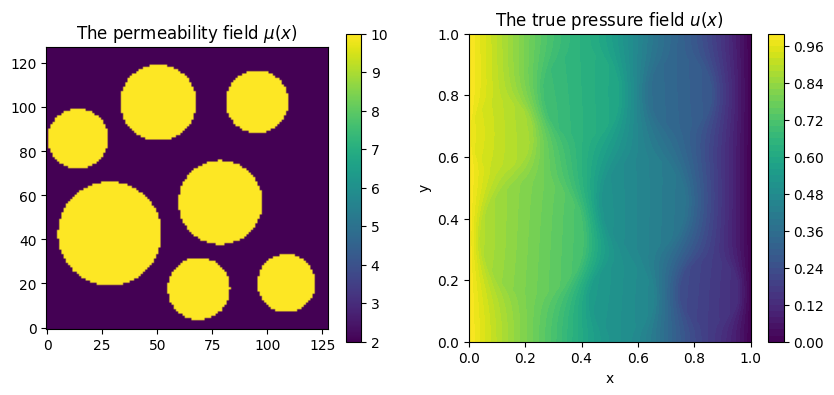

MLP(
  (activation): Tanh()
  (net): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): Linear(in_features=64, out_features=64, bias=True)
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Linear(in_features=64, out_features=64, bias=True)
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [24]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import h5py
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else "cpu")
torch.manual_seed(1234)

with h5py.File('ProblemB_dataset.h5', 'r') as f:
    x_test = torch.tensor(np.array(f['x_test']), dtype=torch.float32)
    u_test = torch.tensor(np.array(f['u_test']), dtype=torch.float32) # Should not be used for training !!!
    mu_field = torch.tensor(np.array(f['mu_field']), dtype=torch.float32)
print('x_test:', x_test.shape, 'u_test:', u_test.shape, 'mu_field:', mu_field.shape)

x_test=x_test.to(device)
u_test =u_test.to(device)

def fun_mu(x, mu=mu_field, resolution=128):
    '''The material property field (get values of material field on any given position x)
    Input:
        x: size(N, 2)
    '''
    mu = mu.reshape(1,-1).to(x)
    delta = 1./(resolution-1)
    #
    x_loc = torch.floor(x[...,0] / delta + 0.5).int()
    y_loc = torch.floor(x[...,1] / delta + 0.5).int()
    loc = y_loc * resolution + x_loc
    #
    mu_new = mu[torch.arange(mu.shape[0]).unsqueeze(1), loc]

    return mu_new.T

mu = fun_mu(x_test)

# ##################################
fig, axes = plt.subplots(1, 2, figsize=(10,4))
cntr = axes[0].imshow(mu.reshape(128,128), origin='lower')
axes[0].set_title(r'The permeability field $\mu(x)$')
plt.colorbar(cntr)

cntr = axes[1].contourf(x_test[:,0].reshape(128, 128), x_test[:,1].reshape(128, 128), u_test.cpu(), levels=50)
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].set_title(r'The true pressure field $u(x)$')
plt.colorbar(cntr)
plt.show()

class MLP(nn.Module):

    def __init__(self, layers_list:list, dtype=None):
        super(MLP, self).__init__()
        # Activation
        self.activation = nn.Tanh()
        # Network Sequential
        net = []
        self.hidden_in = layers_list[0]
        for hidden in layers_list[1:]:
            net.append(nn.Linear(self.hidden_in, hidden, dtype=dtype))
            self.hidden_in = hidden
        self.net = nn.Sequential(*net)

    def forward(self, x):
        # Input and hidden layers
        for net in self.net[:-1]:
            x = net(x)
            x = self.activation(x)
        # Output layer
        x = self.net[-1](x)

        return x
#
model = MLP([2, 64, 64, 64, 64, 1], dtype=torch.float32).to(device)
print(model)

In [29]:
#training-
epochs=10000
N_domain = 2048
N_bc= 512
lambda_bc = 1000.0

optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer,step_size=500,gamma=0.9)

error_history =[]

for epoch in range(epochs + 1):
    model.train()
    optimizer.zero_grad()
    x_dom = torch.rand(N_domain, 2, device=device, requires_grad=True)
    u_dom = model(x_dom)

    grad_u = torch.autograd.grad(
        outputs=u_dom,
        inputs=x_dom,
        grad_outputs=torch.ones_like(u_dom),
        create_graph=True
    )[0]

    grad_u_x = grad_u[:, 0:1]
    grad_u_y = grad_u[:, 1:2]

    mu_val = fun_mu(x_dom).to(device)
    #energy loss formula
    energy_loss = torch.mean(0.5*mu_val*(grad_u_x**2 + grad_u_y**2))

    #sampling coordinates on the boundaries separately
    x_left = torch.cat([torch.zeros(N_bc, 1, device=device), torch.rand(N_bc, 1, device=device)], dim=1)
    x_right = torch.cat([torch.ones(N_bc, 1, device=device), torch.rand(N_bc, 1, device=device)], dim=1)
    x_bottom = torch.cat([torch.rand(N_bc, 1, device=device), torch.zeros(N_bc, 1, device=device)], dim=1)
    x_top = torch.cat([torch.rand(N_bc, 1, device=device), torch.ones(N_bc, 1, device=device)], dim=1)

    #checking boundary values to find total loss
    pred_left = model(x_left)
    loss_left = torch.mean((pred_left - 1.0)**2)

    pred_right = model(x_right)
    loss_right = torch.mean((pred_right - 0.0)**2)

    pred_bottom = model(x_bottom)
    loss_bottom = torch.mean((pred_bottom - (1.0 - x_bottom[:, 0:1]))**2)

    pred_top = model(x_top)
    loss_top = torch.mean((pred_top - (1.0 - x_top[:, 0:1]))**2)

    bc_loss = loss_left + loss_right + loss_bottom + loss_top

    loss = energy_loss + lambda_bc*bc_loss
    loss.backward()
    optimizer.step()
    scheduler.step()

    model.eval()
    with torch.no_grad():
        u_pred = model(x_test).squeeze()
        u_true = u_test.reshape(-1)
        l2_error = torch.sqrt(torch.sum((u_pred- u_true)**2) / torch.sum(u_true**2)).item()
        error_history.append(l2_error)

    if epoch % 500 == 0:
        print(f"epoch {epoch:4d} | loss: {loss.item():.4f} | energy: {energy_loss.item():.4f} | bc loss: {bc_loss.item():.5f} | L2 error: {l2_error:.4f}")

print(f"\nfinal relative L2 error= {error_history[-1]:.4f}")

epoch    0 | loss: 2.4569 | energy: 2.4388 | bc loss: 0.00002 | L2 error: 0.3053
epoch  500 | loss: 2.4385 | energy: 2.4261 | bc loss: 0.00001 | L2 error: 0.0520
epoch 1000 | loss: 2.4270 | energy: 2.4136 | bc loss: 0.00001 | L2 error: 0.0514
epoch 1500 | loss: 2.4499 | energy: 2.4305 | bc loss: 0.00002 | L2 error: 0.0509
epoch 2000 | loss: 2.4571 | energy: 2.4401 | bc loss: 0.00002 | L2 error: 0.0507
epoch 2500 | loss: 2.4924 | energy: 2.4739 | bc loss: 0.00002 | L2 error: 0.0504
epoch 3000 | loss: 2.5904 | energy: 2.4353 | bc loss: 0.00016 | L2 error: 0.0538
epoch 3500 | loss: 2.4868 | energy: 2.4565 | bc loss: 0.00003 | L2 error: 0.0501
epoch 4000 | loss: 2.3571 | energy: 2.3477 | bc loss: 0.00001 | L2 error: 0.0511
epoch 4500 | loss: 2.4764 | energy: 2.4593 | bc loss: 0.00002 | L2 error: 0.0508
epoch 5000 | loss: 2.4278 | energy: 2.4091 | bc loss: 0.00002 | L2 error: 0.0504
epoch 5500 | loss: 2.4179 | energy: 2.3995 | bc loss: 0.00002 | L2 error: 0.0503
epoch 6000 | loss: 2.5197 | 

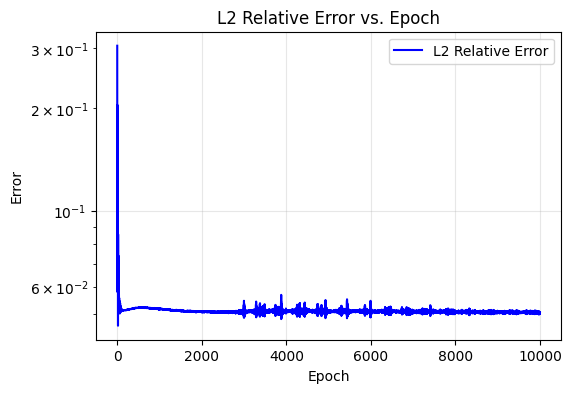

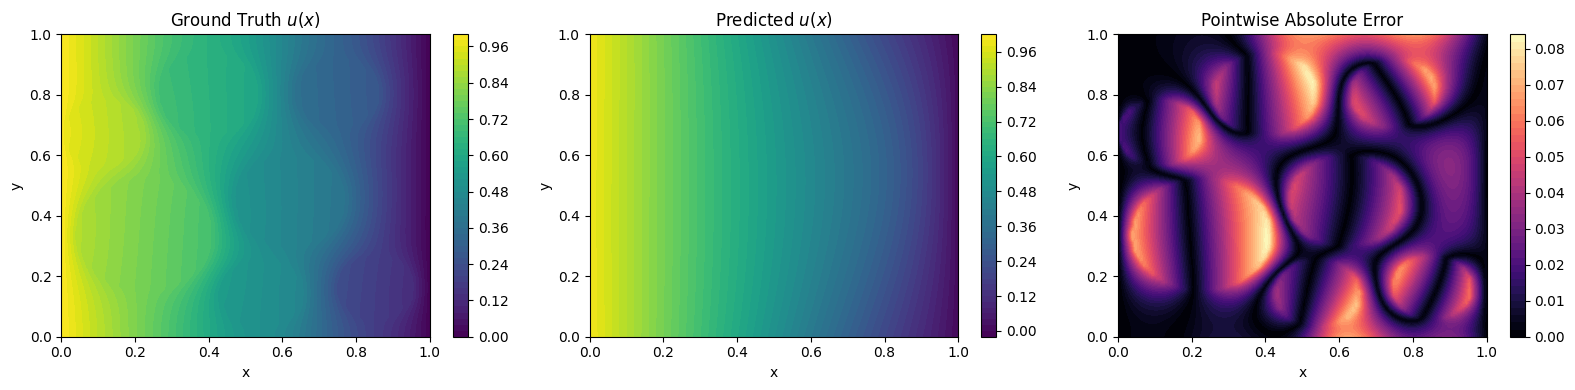

In [30]:
#error plots
plt.figure(figsize=(6, 4))
plt.plot(error_history, label='L2 Relative Error', color='blue')
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Error')
plt.title('L2 Relative Error vs. Epoch')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

model.eval()
with torch.no_grad():
    u_pred_plot = model(x_test).cpu().numpy().reshape(128, 128)
    u_true_plot = u_test.cpu().numpy().reshape(128, 128)
    abs_err_plot = np.abs(u_pred_plot - u_true_plot)

X = x_test[:, 0].cpu().numpy().reshape(128, 128)
Y = x_test[:, 1].cpu().numpy().reshape(128, 128)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

c1 = axes[0].contourf(X, Y, u_true_plot, levels=50, cmap="viridis")
axes[0].set_title('Ground Truth $u(x)$')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
fig.colorbar(c1, ax=axes[0])

c2 = axes[1].contourf(X, Y, u_pred_plot, levels=50, cmap="viridis")
axes[1].set_title('Predicted $u(x)$')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
fig.colorbar(c2, ax=axes[1])

c3 = axes[2].contourf(X, Y, abs_err_plot, levels=50, cmap="magma")
axes[2].set_title('Pointwise Absolute Error')
axes[2].set_xlabel('x')
axes[2].set_ylabel('y')
fig.colorbar(c3, ax=axes[2])

plt.tight_layout()
plt.show()